In [1]:
# Cell 1 — Environment setup (same as your working config)
import os

# Clear conflicting SPARK_HOME
if 'SPARK_HOME' in os.environ:
    del os.environ['SPARK_HOME']

os.environ['JAVA_HOME'] = r'C:\Program Files\Eclipse Adoptium\jdk-11.0.30.7-hotspot'
os.environ['HADOOP_HOME'] = r'C:\hadoop-3.2.2\hadoop-3.2.2'
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'
os.environ['PYSPARK_PYTHON'] = r'C:\Users\saich\ml-portfolio\project2-bigdata-forecasting\venv\Scripts\python.exe'
os.environ['PYSPARK_DRIVER_PYTHON'] = r'C:\Users\saich\ml-portfolio\project2-bigdata-forecasting\venv\Scripts\python.exe'

print("✅ Environment configured")
print(f"   JAVA_HOME: {os.environ.get('JAVA_HOME')}")

✅ Environment configured
   JAVA_HOME: C:\Program Files\Eclipse Adoptium\jdk-11.0.30.7-hotspot


In [2]:
# Cell 2 — Imports
import glob
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, LongType,
    DoubleType, TimestampType
)

load_dotenv()
sns.set_theme(style='whitegrid')

print("✅ Imports loaded")

✅ Imports loaded


In [3]:
# Cell 3 — Spark Session (your working config)
spark = SparkSession.builder \
    .appName("Project2-DataCleaning") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress",
            "127.0.0.1") \
    .config("spark.sql.shuffle.partitions",
            "8") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config(
        "spark.sql.parquet.int96RebaseMode",
        "LEGACY") \
    .config(
        "spark.sql.parquet.datetimeRebaseMode",
        "LEGACY") \
    .config(
        "spark.sql.parquet.enableVectorizedReader",
        "false") \
    .config(
        "spark.sql.parquet.mergeSchema",
        "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"✅ Spark {spark.version} ready")
print(f"   Cores: "
      f"{spark.sparkContext.defaultParallelism}")

✅ Spark 3.5.1 ready
   Cores: 8


In [4]:
# Cell 4 — Load using your schema-aware pattern
schema = StructType([
    StructField("VendorID",
                LongType(), True),
    StructField("tpep_pickup_datetime",
                TimestampType(), True),
    StructField("tpep_dropoff_datetime",
                TimestampType(), True),
    StructField("passenger_count",
                LongType(), True),
    StructField("trip_distance",
                DoubleType(), True),
    StructField("RatecodeID",
                LongType(), True),
    StructField("store_and_fwd_flag",
                StringType(), True),
    StructField("PULocationID",
                LongType(), True),
    StructField("DOLocationID",
                LongType(), True),
    StructField("payment_type",
                LongType(), True),
    StructField("fare_amount",
                DoubleType(), True),
    StructField("extra",
                DoubleType(), True),
    StructField("mta_tax",
                DoubleType(), True),
    StructField("tip_amount",
                DoubleType(), True),
    StructField("tolls_amount",
                DoubleType(), True),
    StructField("improvement_surcharge",
                DoubleType(), True),
    StructField("total_amount",
                DoubleType(), True),
    StructField("congestion_surcharge",
                DoubleType(), True),
    StructField("airport_fee",
                DoubleType(), True),
])

# Load each file and cast to consistent schema
raw_dir = "../data/raw"
parquet_files = sorted(
    glob.glob(f"{raw_dir}/*.parquet"))

print(f"Loading {len(parquet_files)} files...")

dfs = []
for pq_file in parquet_files:
    temp_df = spark.read.parquet(pq_file)
    for field in schema.fields:
        if field.name.lower() in [
            c.lower() for c in temp_df.columns
        ]:
            col_actual = next(
                c for c in temp_df.columns
                if c.lower() == field.name.lower()
            )
            temp_df = temp_df.withColumn(
                field.name,
                F.col(col_actual).cast(
                    field.dataType)
            )
    temp_df = temp_df.select(
        [f.name for f in schema.fields])
    dfs.append(temp_df)
    print(f"  ✅ Loaded "
          f"{pq_file.split('/')[-1]}")

df = dfs[0]
for temp_df in dfs[1:]:
    df = df.unionByName(
        temp_df, allowMissingColumns=True)

raw_count = df.count()
print(f"\n✅ Raw data loaded: "
      f"{raw_count:,} records")

Loading 3 files...
  ✅ Loaded raw\yellow_tripdata_2023-01.parquet
  ✅ Loaded raw\yellow_tripdata_2023-02.parquet
  ✅ Loaded raw\yellow_tripdata_2023-03.parquet

✅ Raw data loaded: 9,384,487 records


In [5]:
# Cell 5 — Count records to remove per rule
print("=== CLEANING RULES ANALYSIS ===\n")

# Rule 1: Date range — only keep 2023 data
# Your EDA showed dates from 2001-2023
bad_dates = df.filter(
    (F.year('tpep_pickup_datetime') != 2023) |
    (F.col('tpep_pickup_datetime').isNull())
).count()

# Rule 2: Negative or zero fares
bad_fares = df.filter(
    F.col('fare_amount') <= 0
).count()

# Rule 3: Zero or negative distance
bad_distance = df.filter(
    F.col('trip_distance') <= 0
).count()

# Rule 4: Extreme fares (outliers > $500)
extreme_fares = df.filter(
    F.col('fare_amount') > 500
).count()

# Rule 5: Extreme distances (> 100 miles)
extreme_dist = df.filter(
    F.col('trip_distance') > 100
).count()

# Rule 6: Null pickup datetime
null_dt = df.filter(
    F.col('tpep_pickup_datetime').isNull()
).count()

# Rule 7: Trip duration issues
# dropoff before pickup
bad_duration = df.filter(
    F.col('tpep_dropoff_datetime') <=
    F.col('tpep_pickup_datetime')
).count()

print(f"{'Rule':<35} {'Count':>10} "
      f"{'% of Total':>12}")
print("-" * 60)

rules = [
    ("Wrong year (not 2023)",  bad_dates),
    ("Zero/negative fares",    bad_fares),
    ("Zero/negative distance", bad_distance),
    ("Extreme fares (>$500)",  extreme_fares),
    ("Extreme distance (>100mi)", extreme_dist),
    ("Null pickup datetime",   null_dt),
    ("Invalid trip duration",  bad_duration),
]

for rule, count in rules:
    pct = count / raw_count * 100
    print(f"{rule:<35} {count:>10,} "
          f"{pct:>11.2f}%")

=== CLEANING RULES ANALYSIS ===

Rule                                     Count   % of Total
------------------------------------------------------------
Wrong year (not 2023)                       54        0.00%
Zero/negative fares                     82,873        0.88%
Zero/negative distance                 135,488        1.44%
Extreme fares (>$500)                       83        0.00%
Extreme distance (>100mi)                  297        0.00%
Null pickup datetime                         0        0.00%
Invalid trip duration                    3,839        0.04%


In [6]:
# Cell 6 — Clean the data
print("Applying cleaning pipeline...")

df_clean = df.filter(
    # Rule 1: Only 2023 data
    (F.year('tpep_pickup_datetime') == 2023) &

    # Rule 2: Valid fares
    (F.col('fare_amount') > 0) &
    (F.col('fare_amount') <= 500) &

    # Rule 3: Valid distance
    (F.col('trip_distance') > 0) &
    (F.col('trip_distance') <= 100) &

    # Rule 4: No null datetimes
    F.col('tpep_pickup_datetime').isNotNull() &
    F.col('tpep_dropoff_datetime').isNotNull() &

    # Rule 5: Valid duration
    (F.col('tpep_dropoff_datetime') >
     F.col('tpep_pickup_datetime')) &

    # Rule 6: Valid passenger count
    (F.col('passenger_count') > 0) &
    (F.col('passenger_count') <= 6)
)

clean_count  = df_clean.count()
removed      = raw_count - clean_count
pct_retained = clean_count / raw_count * 100
pct_removed  = 100 - pct_retained

print(f"\n=== CLEANING RESULTS ===")
print(f"Raw records:     {raw_count:,}")
print(f"Clean records:   {clean_count:,}")
print(f"Records removed: {removed:,} "
      f"({pct_removed:.2f}%)")
print(f"Records retained:{pct_retained:.2f}%")

Applying cleaning pipeline...

=== CLEANING RESULTS ===
Raw records:     9,384,487
Clean records:   8,807,070
Records removed: 577,417 (6.15%)
Records retained:93.85%


In [7]:
# Cell 7 — Add derived columns during cleaning
print("Adding derived columns...")

df_clean = df_clean.withColumn(
    'trip_duration_min',
    (F.unix_timestamp('tpep_dropoff_datetime') -
     F.unix_timestamp('tpep_pickup_datetime'))
    / 60.0
).withColumn(
    'pickup_date',
    F.to_date('tpep_pickup_datetime')
).withColumn(
    'pickup_hour_of_day',
    F.hour('tpep_pickup_datetime')
).withColumn(
    'pickup_day_of_week',
    F.dayofweek('tpep_pickup_datetime')
).withColumn(
    'pickup_month',
    F.month('tpep_pickup_datetime')
).withColumn(
    'is_weekend',
    F.when(
        F.dayofweek('tpep_pickup_datetime')
        .isin([1, 7]), 1
    ).otherwise(0)
).withColumn(
    'speed_mph',
    F.when(
        F.col('trip_duration_min') > 0,
        F.col('trip_distance') /
        (F.col('trip_duration_min') / 60)
    ).otherwise(None)
)

# Also filter unrealistic speeds
df_clean = df_clean.filter(
    (F.col('trip_duration_min') > 0) &
    (F.col('trip_duration_min') <= 180) &
    (F.col('speed_mph').isNull() |
     (F.col('speed_mph') <= 80))
)

final_count = df_clean.count()
print(f"✅ Derived columns added")
print(f"   Final clean count: "
      f"{final_count:,}")
print(f"\nNew columns added:")
new_cols = ['trip_duration_min', 'pickup_date',
            'pickup_hour_of_day',
            'pickup_day_of_week',
            'pickup_month', 'is_weekend',
            'speed_mph']
for col in new_cols:
    print(f"  → {col}")

Adding derived columns...
✅ Derived columns added
   Final clean count: 8,794,039

New columns added:
  → trip_duration_min
  → pickup_date
  → pickup_hour_of_day
  → pickup_day_of_week
  → pickup_month
  → is_weekend
  → speed_mph


In [8]:
# Cell 8 — Verify cleaned data
print("=== CLEANING VERIFICATION ===\n")

# Date range check
date_range = df_clean.select(
    F.min('tpep_pickup_datetime').alias(
        'earliest'),
    F.max('tpep_pickup_datetime').alias(
        'latest')
).collect()[0]

print(f"Date range after cleaning:")
print(f"  Earliest: {date_range['earliest']}")
print(f"  Latest:   {date_range['latest']}")

# Stats on key columns
print(f"\nKey statistics after cleaning:")
df_clean.select(
    'fare_amount',
    'trip_distance',
    'trip_duration_min',
    'passenger_count',
    'speed_mph'
).describe().show()

# Monthly distribution
print("Records per month:")
df_clean.withColumn(
    'month',
    F.date_format('tpep_pickup_datetime',
                  'yyyy-MM')
).groupBy('month') \
 .count() \
 .orderBy('month') \
 .show()

=== CLEANING VERIFICATION ===

Date range after cleaning:
  Earliest: 2023-01-01 00:00:05
  Latest:   2023-04-05 20:17:42

Key statistics after cleaning:
+-------+------------------+------------------+--------------------+------------------+--------------------+
|summary|       fare_amount|     trip_distance|   trip_duration_min|   passenger_count|           speed_mph|
+-------+------------------+------------------+--------------------+------------------+--------------------+
|  count|           8794039|           8794039|             8794039|           8794039|             8794039|
|   mean|18.702813152182774|3.4057006399446195|  14.999911980150046|1.3803377492412758|  11.928540359775095|
| stddev|17.030255530533225| 4.406959674002089|  11.597607082474507|0.8816806042004466|    6.71128697790817|
|    min|              0.01|              0.01|0.016666666666666666|                 1|0.003550646020317586|
|    max|             500.0|             99.09|  179.71666666666667|               

Creating before/after visualization...


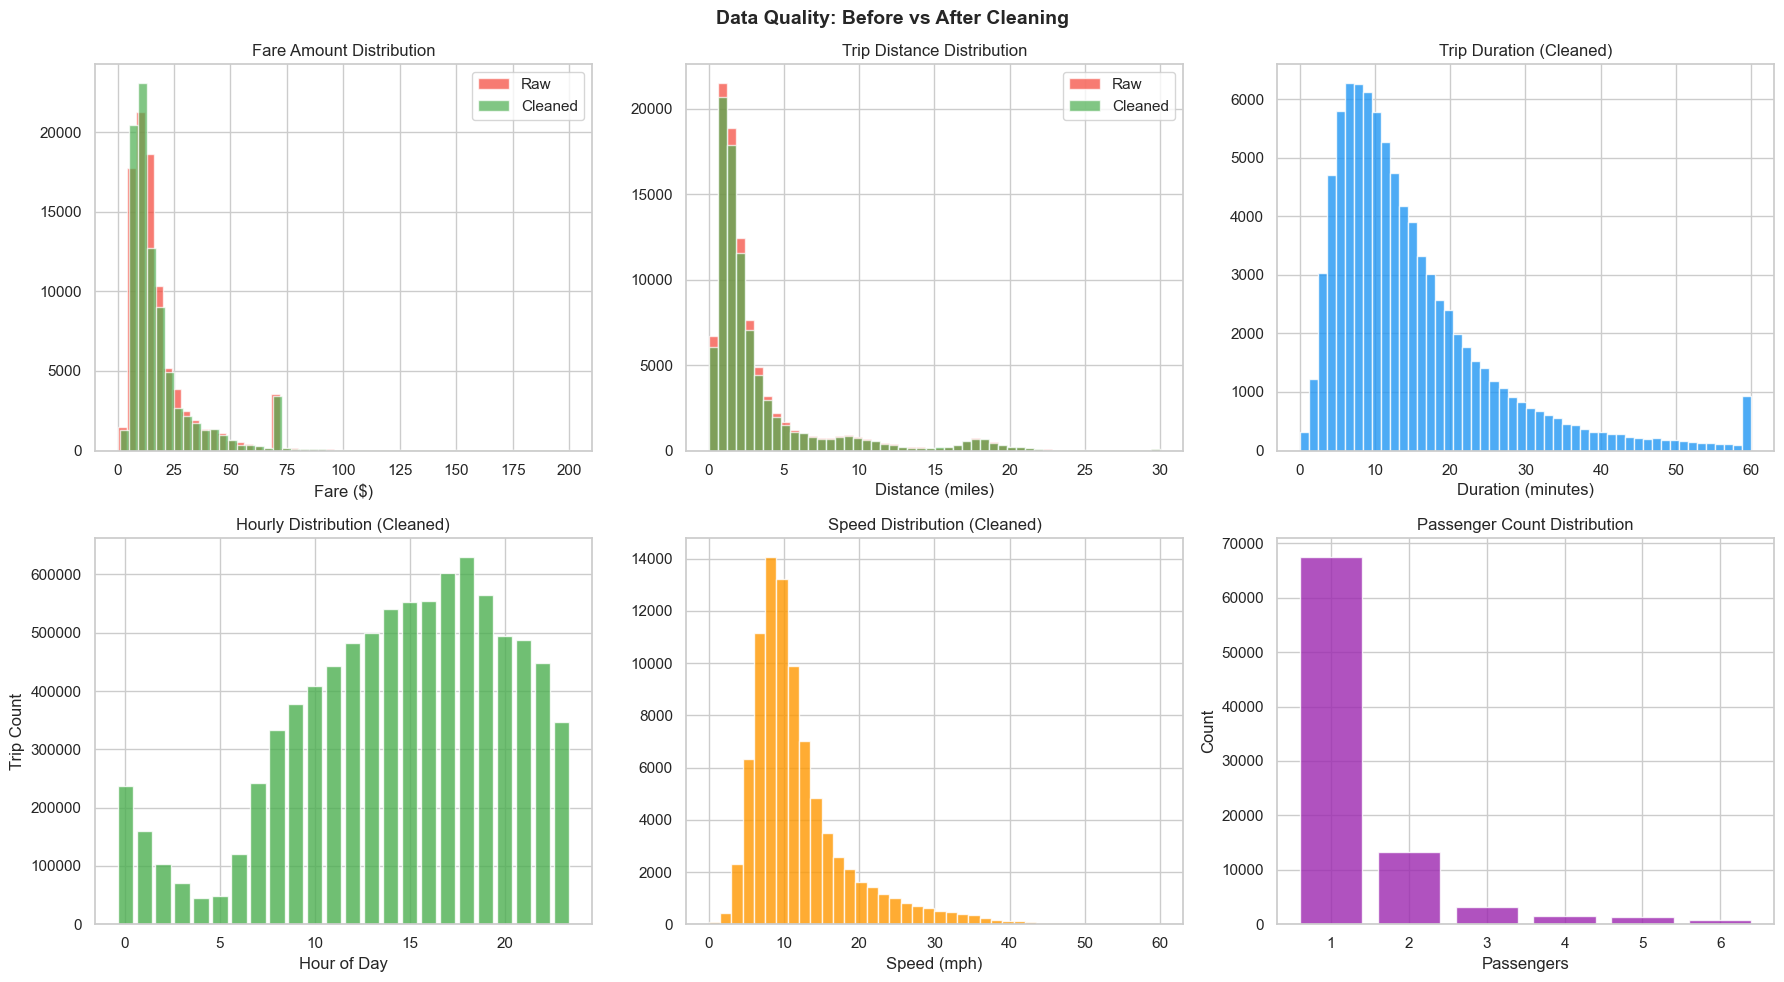

In [9]:
# Cell 9 — Before vs After comparison
print("Creating before/after visualization...")

# Sample for comparison
raw_sample = df.filter(
    F.year('tpep_pickup_datetime') == 2023
).sample(0.01).toPandas()

clean_sample = df_clean.sample(0.01).toPandas()

fig, axes = plt.subplots(2, 3,
                          figsize=(18, 10))

# Fare distribution
axes[0,0].hist(
    raw_sample['fare_amount'].clip(0, 200),
    bins=50, color='#F44336',
    alpha=0.7, label='Raw')
axes[0,0].hist(
    clean_sample['fare_amount'].clip(0, 200),
    bins=50, color='#4CAF50',
    alpha=0.7, label='Cleaned')
axes[0,0].set_title('Fare Amount Distribution')
axes[0,0].set_xlabel('Fare ($)')
axes[0,0].legend()

# Distance distribution
axes[0,1].hist(
    raw_sample['trip_distance'].clip(0, 30),
    bins=50, color='#F44336',
    alpha=0.7, label='Raw')
axes[0,1].hist(
    clean_sample['trip_distance'].clip(0, 30),
    bins=50, color='#4CAF50',
    alpha=0.7, label='Cleaned')
axes[0,1].set_title('Trip Distance Distribution')
axes[0,1].set_xlabel('Distance (miles)')
axes[0,1].legend()

# Duration distribution
axes[0,2].hist(
    clean_sample['trip_duration_min'].clip(0, 60),
    bins=50, color='#2196F3', alpha=0.8)
axes[0,2].set_title('Trip Duration (Cleaned)')
axes[0,2].set_xlabel('Duration (minutes)')

# Hourly distribution after cleaning
hourly_clean = df_clean.withColumn(
    'hour', F.hour('tpep_pickup_datetime')
).groupBy('hour').count()\
 .orderBy('hour').toPandas()

axes[1,0].bar(
    hourly_clean['hour'],
    hourly_clean['count'],
    color='#4CAF50', alpha=0.8)
axes[1,0].set_title(
    'Hourly Distribution (Cleaned)')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Trip Count')

# Speed distribution
axes[1,1].hist(
    clean_sample['speed_mph'].dropna().clip(0, 60),
    bins=40, color='#FF9800', alpha=0.8)
axes[1,1].set_title(
    'Speed Distribution (Cleaned)')
axes[1,1].set_xlabel('Speed (mph)')

# Passenger count
pax_counts = clean_sample[
    'passenger_count'].value_counts()\
    .sort_index()
axes[1,2].bar(
    pax_counts.index, pax_counts.values,
    color='#9C27B0', alpha=0.8)
axes[1,2].set_title(
    'Passenger Count Distribution')
axes[1,2].set_xlabel('Passengers')
axes[1,2].set_ylabel('Count')

plt.suptitle(
    'Data Quality: Before vs After Cleaning',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/cleaning_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Cell 10 — Save cleaned data
import os

os.makedirs('../data/processed', exist_ok=True)

output_path = '../data/processed/taxi_clean'
print(f"Saving cleaned data to: {output_path}")
print("This may take 1-2 minutes...")

# Save as Parquet — partitioned by date
# Partitioning makes future reads faster
df_clean.write \
    .mode('overwrite') \
    .partitionBy('pickup_date') \
    .parquet(output_path)

print(f"✅ Saved to {output_path}/")
print(f"   Format: Parquet")
print(f"   Partitioned by: pickup_date")
print(f"   Records: {final_count:,}")

# Verify save
df_verify = spark.read.parquet(output_path)
verify_count = df_verify.count()
print(f"\n✅ Verification read: "
      f"{verify_count:,} records")

Saving cleaned data to: ../data/processed/taxi_clean
This may take 1-2 minutes...
✅ Saved to ../data/processed/taxi_clean/
   Format: Parquet
   Partitioned by: pickup_date
   Records: 8,794,039

✅ Verification read: 8,794,039 records


In [11]:
# Cell 11 — Upload to S3
import boto3

print("Uploading cleaned data to S3...")

s3 = boto3.client(
    's3',
    aws_access_key_id=os.getenv(
        'AWS_ACCESS_KEY_ID'),
    aws_secret_access_key=os.getenv(
        'AWS_SECRET_ACCESS_KEY'),
    region_name=os.getenv('AWS_DEFAULT_REGION')
)

bucket = os.getenv('S3_BUCKET_DATA')

# Save a single CSV version for easier access
clean_csv_path = \
    '../data/processed/taxi_clean_sample.csv'

# Sample 100K records for CSV
sample_pdf = df_clean.sample(
    fraction=min(100000/final_count, 1.0),
    seed=42
).toPandas()

sample_pdf.to_csv(clean_csv_path, index=False)

s3.upload_file(
    clean_csv_path,
    bucket,
    'project2/processed/taxi_clean_sample.csv'
)
print(f"✅ Sample CSV uploaded to S3")
print(f"   {len(sample_pdf):,} records")

Uploading cleaned data to S3...
✅ Sample CSV uploaded to S3
   100,239 records


In [12]:
# Cell 12 — Recreate hourly stats on clean data
print("Creating hourly aggregations "
      "on CLEAN data...")

hourly_clean_df = df_clean.withColumn(
    'pickup_hour',
    F.date_trunc('hour',
                 'tpep_pickup_datetime')
).groupBy('pickup_hour') \
 .agg(
    F.count('*').alias('trip_count'),
    F.avg('fare_amount').alias('avg_fare'),
    F.avg('trip_distance').alias(
        'avg_distance'),
    F.avg('passenger_count').alias(
        'avg_passengers'),
    F.sum('total_amount').alias(
        'total_revenue'),
    F.avg('tip_amount').alias('avg_tip'),
    F.avg('trip_duration_min').alias(
        'avg_duration_min'),
    F.avg('speed_mph').alias('avg_speed_mph'),
    F.first('pickup_hour_of_day').alias(
        'hour_of_day'),
    F.first('pickup_day_of_week').alias(
        'day_of_week'),
    F.first('is_weekend').alias('is_weekend'),
    F.first('pickup_month').alias('month')
).orderBy('pickup_hour')

hourly_clean_pdf = hourly_clean_df.toPandas()
hourly_clean_pdf['pickup_hour'] = \
    pd.to_datetime(hourly_clean_pdf['pickup_hour'])
hourly_clean_pdf = hourly_clean_pdf\
    .sort_values('pickup_hour')\
    .reset_index(drop=True)

print(f"✅ Clean hourly data ready")
print(f"   Hours: {len(hourly_clean_pdf):,}")
print(f"   Date range: "
      f"{hourly_clean_pdf['pickup_hour'].min()}"
      f" to "
      f"{hourly_clean_pdf['pickup_hour'].max()}")

# Save
hourly_path = \
    '../data/processed/hourly_clean.csv'
hourly_clean_pdf.to_csv(hourly_path,
                         index=False)

s3.upload_file(
    hourly_path, bucket,
    'project2/processed/hourly_clean.csv')

print(f"\n✅ Saved hourly_clean.csv locally "
      f"and to S3")

Creating hourly aggregations on CLEAN data...
✅ Clean hourly data ready
   Hours: 2,190
   Date range: 2023-01-01 00:00:00 to 2023-04-05 20:00:00

✅ Saved hourly_clean.csv locally and to S3


In [13]:
# Cell 13 — Save cleaning summary
cleaning_summary = {
    'raw_records':       int(raw_count),
    'clean_records':     int(final_count),
    'records_removed':   int(raw_count - final_count),
    'retention_rate':    round(
        final_count/raw_count*100, 2),
    'cleaning_rules': {
        'date_filter':   'Only 2023 data kept',
        'fare_range':    '> $0 and <= $500',
        'distance_range':'> 0 and <= 100 miles',
        'duration_range':'> 0 and <= 180 min',
        'speed_limit':   '<= 80 mph',
        'passengers':    '1 to 6',
    },
    'new_columns_added': [
        'trip_duration_min',
        'pickup_date',
        'pickup_hour_of_day',
        'pickup_day_of_week',
        'pickup_month',
        'is_weekend',
        'speed_mph'
    ],
    'output_format':     'Parquet partitioned by date',
    'output_location':   'data/processed/taxi_clean/',
    's3_location':       (
        f"s3://{bucket}/"
        f"project2/processed/"
    ),
    'hourly_clean_hours': int(
        len(hourly_clean_pdf)),
}

with open('../logs/cleaning_summary.json',
          'w') as f:
    json.dump(cleaning_summary, f, indent=4)

print("✅ Cleaning summary saved")
print(json.dumps(cleaning_summary, indent=4))

spark.stop()
print("\n✅ Spark stopped cleanly")

✅ Cleaning summary saved
{
    "raw_records": 9384487,
    "clean_records": 8794039,
    "records_removed": 590448,
    "retention_rate": 93.71,
    "cleaning_rules": {
        "date_filter": "Only 2023 data kept",
        "fare_range": "> $0 and <= $500",
        "distance_range": "> 0 and <= 100 miles",
        "duration_range": "> 0 and <= 180 min",
        "speed_limit": "<= 80 mph",
        "passengers": "1 to 6"
    },
    "new_columns_added": [
        "trip_duration_min",
        "pickup_date",
        "pickup_hour_of_day",
        "pickup_day_of_week",
        "pickup_month",
        "is_weekend",
        "speed_mph"
    ],
    "output_format": "Parquet partitioned by date",
    "output_location": "data/processed/taxi_clean/",
    "s3_location": "s3://document-ai-portfolio-data/project2/processed/",
    "hourly_clean_hours": 2190
}

✅ Spark stopped cleanly
